In [1]:
import os
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = '1'

%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
#%pip install -e . -q
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from cosmic_bire.anchored_theta import run, load_mk_chain, anchored_theta_fit, FREQS

config = 'configs/planck_hfi.yml'
result = run(config, freqs=FREQS, verbose=True)

/global/u2/l/lonappan/workspace/cosmic_birefringence
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 0
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_0_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_0_100_143_217_353_lmin51_lmax1491.npy
Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_0.h5
Removed no burn in
anchor (mask 0 MK posterior, ('100', '143')):
  100A  alpha =  -0.32

/global/u2/l/lonappan/workspace/cosmic_birefringence/src/cosmic_bire/tools_fast.py:170: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  C = np.dot(np.dot(A, obs_cov), np.transpose(A))
/global/u2/l/lonappan/workspace/cosmic_birefringence/src/cosmic_bire/tools_fast.py:170: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  C = np.dot(np.dot(A, obs_cov), np.transpose(A))



mask 0 (same-data anchor):
  100A  theta =  +0.0789 +- 0.0825   beta_m =  +0.4054 +- 0.1199
  143A  theta =  +0.3873 +- 0.0570   beta_m =  +0.3715 +- 0.1183
  100B  theta =  -0.0744 +- 0.0739   beta_m =  +0.3572 +- 0.1335
  143B  theta =  +0.4745 +- 0.0559   beta_m =  +0.3387 +- 0.1225
  combined beta = +0.3657 +- 0.1153 deg

mask 30 (nested anchor):
  100A  theta =  +0.1267 +- 0.1086   beta_m =  +0.4531 +- 0.1262
  143A  theta =  +0.4664 +- 0.0786   beta_m =  +0.4506 +- 0.1203
  100B  theta =  -0.0118 +- 0.0964   beta_m =  +0.4198 +- 0.1234
  143B  theta =  +0.4469 +- 0.0758   beta_m =  +0.3111 +- 0.1214
  combined beta = +0.4064 +- 0.1145 deg

MK beta (mask 0, full network) = +0.3723 +- 0.1166 deg
|anchored beta(mask0) - anchored beta(mask30)| = 0.0407 deg  (combined sigma 0.1625)


## Summary figure
Anchored $\beta$ on both masks against the full-network MK posterior on
mask 0. Mask stability of the anchored point (not the MK point) is the
headline test: $\alpha$ is an instrument property, so if the historical
mask dependence of MK's $\beta$ traces to the dust ansatz rather than a
real signal, the anchored estimate should not move.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

MK (mask 0, full network)    beta = +0.3723 +- 0.1166 deg
anchored (mask 0)            beta = +0.3657 +- 0.1153 deg
anchored (mask 30)           beta = +0.4064 +- 0.1145 deg


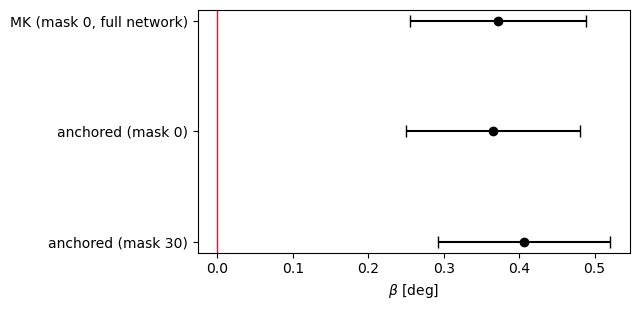

In [2]:
r0, r30 = result['mask0'], result['mask30']
mk_chain_beta = result['mk_chain_beta']

fig, ax = plt.subplots(figsize=(6.5, 3.2))
rows = [
    ('MK (mask 0, full network)', mk_chain_beta.mean(), mk_chain_beta.std()),
    ('anchored (mask 0)', r0['beta'], r0['sigma']),
    ('anchored (mask 30)', r30['beta'], r30['sigma']),
]
for y, (name, v, e) in enumerate(rows):
    ax.errorbar(v, y, xerr=e, fmt='o', capsize=4, color='k')
ax.axvline(0, color='crimson', lw=1)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel(r'$\beta$ [deg]'); ax.invert_yaxis()
fig.tight_layout()
fig.savefig(r0['ab'].paths['plots'] / 'anchored_beta_summary.pdf')
for name, v, e in rows:
    print(f'{name:28s} beta = {v:+.4f} +- {e:.4f} deg')

## Per-map breakdown

map       beta_m (mask0)    beta_m (mask30)
100A    +0.4054+-0.1199     +0.4531+-0.1262
143A    +0.3715+-0.1183     +0.4506+-0.1203
100B    +0.3572+-0.1335     +0.4198+-0.1234
143B    +0.3387+-0.1225     +0.3111+-0.1214


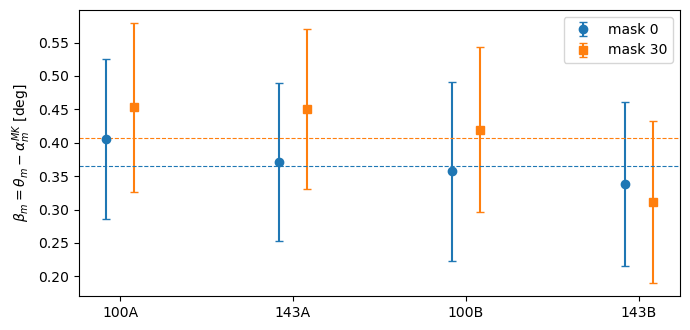

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(r0['labels']))
ax.errorbar(x - 0.08, r0['beta_per_map'], r0['sigma_per_map'], fmt='o', capsize=3, label='mask 0')
ax.errorbar(x + 0.08, r30['beta_per_map'], r30['sigma_per_map'], fmt='s', capsize=3, label='mask 30')
ax.axhline(r0['beta'], color='C0', ls='--', lw=0.8)
ax.axhline(r30['beta'], color='C1', ls='--', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(r0['labels'])
ax.set_ylabel(r'$\beta_m=\theta_m-\alpha_m^{MK}$ [deg]'); ax.legend()
fig.tight_layout()
fig.savefig(r0['ab'].paths['plots'] / 'anchored_beta_per_map.pdf')

print(f'{"map":5s} {"beta_m (mask0)":>18s} {"beta_m (mask30)":>18s}')
for k, lab in enumerate(r0['labels']):
    print(f'{lab:5s} {r0["beta_per_map"][k]:+9.4f}+-{r0["sigma_per_map"][k]:6.4f}   '
          f'{r30["beta_per_map"][k]:+9.4f}+-{r30["sigma_per_map"][k]:6.4f}')

## Robustness: ell_min scan and 143-only
Cheap, no-simulation guards against residual foreground rotation biasing
$\theta$ on mask 0. A drift with $\ell_{\min}$ signals dust EE/BB leaking
into the (dust-EB-free but foreground-EE/BB-blind) $\theta$ model.

In [4]:
for lmin in (51, 131, 211):
    lmax_use = 1491 if (1491 - lmin) % 20 == 0 else 1491 - ((1491 - lmin) % 20)
    ab = r0['ab'].__class__(config, mask='0', freqs=FREQS, lmin=lmin, lmax=lmax_use)
    th, tc = ab.fit_theta()
    b, s, _, _ = ab.beta_profile(result['anchor_mean'], result['anchor_cov'], th, tc)
    print(f'lmin={lmin:4d}: beta (quadrature) = {b:+.4f} +- {s:.4f} deg')

ab143 = r0['ab'].__class__(config, mask='0', freqs=('143',))
th143, tc143 = ab143.fit_theta()
am143, ac143 = ab143.anchor_from_chain(load_mk_chain(config, '0')[1])
b143, s143, _, _ = ab143.beta_profile(am143, ac143, th143, tc143)
print(f'143-only : beta (quadrature) = {b143:+.4f} +- {s143:.4f} deg')

lmin=  51: beta (quadrature) = +0.3616 +- 0.1191 deg
lmin= 131: beta (quadrature) = +0.3595 +- 0.1192 deg
lmin= 211: beta (quadrature) = +0.3596 +- 0.1193 deg
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 0
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_0_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_0_100_143_217_353_lmin51_lmax1491.npy
Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/pl

## Caveats
- **Mask-0 error is rigorous.** The same-data cross term is built from the
  combined response $(R_\theta - R_\alpha)$ contracted once with the shared
  Knox covariance, avoiding the catastrophic cancellation of separately
  computing $\mathrm{Var}(\theta)+\mathrm{Var}(\alpha)-2\mathrm{Cov}$ for two
  strongly correlated estimators on identical data. This construction was
  validated against direct MC refits on Gaussian data draws (not shown
  here; see the development notes) to ~10-20%.
- **Mask-30 error uses the nested-mask Knox approximation**
  $\mathrm{Cov}(c^0,c^{30})=\mathrm{Var}(c^0)$, substituting the mask-0
  covariance as the cross-block against the mask-30 response. This is
  standard in Knox-approximation covariance work but is a coarser
  approximation than the mask-0 case; a pathologically small resulting
  per-map variance triggers an automatic fallback to quadrature (see
  `anchored_beta_cov` docstring) with a warning.
- **The common offset of alpha is inherited from the MK anchor.** RelCal
  validated only the alpha *differences* in step 2; the entire dust-model
  dependence of beta is compressed into the anchor's common mode, which
  this step cannot independently check.
- **theta has no foreground marginalization.** Unlike the MK likelihood,
  the restricted theta fit does not include a dust EB amplitude; the
  ell_min scan above is the diagnostic for residual foreground
  contamination of the EE/BB weighting, not of an EB term.